# 01 — EDA и предобработка данных

**Проект:** Прогноз оттока клиентов телеком-оператора  
**Датасет:** IBM Telco Customer Churn (Kaggle)  
**Чеклист:** пункты 3 (EDA и эксперименты с метриками) и 5 (структура `src/`)  

Цели ноутбука:
1. Загрузить и первично изучить датасет
2. Провести EDA: типы данных, пропуски, распределения, корреляции
3. Выполнить предобработку (идентичную `src/data/preprocessor.py`)
4. Сохранить `train.csv`, `val.csv`, `test.csv` в `data/processed/`

## 0. Импорты и настройки

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Воспроизводимость (чеклист 4: фиксируем random_state)
RANDOM_STATE = 42

# Пути (относительно корня project/)
DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 4)
sns.set_theme(style='whitegrid', palette='Set2')

print('Imports OK')
print(f'Processed data will be saved to: {DATA_PROCESSED.resolve()}')

Imports OK
Processed data will be saved to: C:\AIE_homeworks\AIE-Ulyankin-V\project\data\processed


## 1. Загрузка данных

Датасет нужно скачать с Kaggle вручную и положить в `data/raw/`.

```bash
# Способ 1: вручную
# Скачай с https://www.kaggle.com/datasets/blastchar/telco-customer-churn
# Положи файл: data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv

# Способ 2: через Kaggle API (нужен ~/.kaggle/kaggle.json)
# kaggle datasets download -d blastchar/telco-customer-churn -p data/raw --unzip
```

In [3]:
CSV_NAME = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
csv_path = DATA_RAW / CSV_NAME

if not csv_path.exists():
    raise FileNotFoundError(
        f'Файл не найден: {csv_path}\n'
        'Скачайте датасет с https://www.kaggle.com/datasets/blastchar/telco-customer-churn\n'
        f'и положите в {DATA_RAW.resolve()}'
    )

df = pd.read_csv(csv_path)
print(f'Датасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head(3)

Датасет загружен: 7043 строк, 21 столбцов


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Первичный осмотр (чеклист 3: EDA)

In [4]:
print('=== Типы данных ===')
print(df.dtypes)
print(f'\n=== Форма: {df.shape} ===')

=== Типы данных ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Форма: (7043, 21) ===


In [5]:
print('=== Пропущенные значения ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Пропусков нет')

# TotalCharges: колонка строковая, пустые строки = пропуски
print('\n=== TotalCharges — уникальные нечисловые значения ===')
tc_bad = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]['TotalCharges'].unique()
print(tc_bad)

=== Пропущенные значения ===
Пропусков нет

=== TotalCharges — уникальные нечисловые значения ===
[' ']


In [6]:
print('=== Статистика числовых признаков ===')
df.describe()

=== Статистика числовых признаков ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Распределение целевой переменной

> **Чеклист 3:** анализируем несбалансированность классов — важно для выбора метрик.

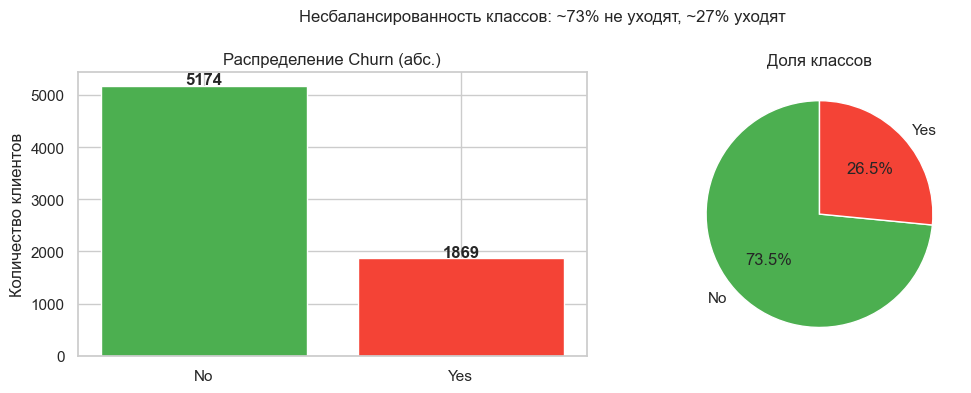

Класс 0 (No churn): 5174 (73.5%)
Класс 1 (Churn):    1869 (26.5%)

⚠️  Дисбаланс ~1:2.7 → используем ROC-AUC и F1 вместо Accuracy (чеклист 4)


In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(churn_counts.index, churn_counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('Распределение Churn (абс.)')
axes[0].set_ylabel('Количество клиентов')
for i, (idx, val) in enumerate(churn_counts.items()):
    axes[0].text(i, val + 30, str(val), ha='center', fontweight='bold')

axes[1].pie(churn_pct.values, labels=churn_pct.index,
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Доля классов')

plt.suptitle('Несбалансированность классов: ~73% не уходят, ~27% уходят', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Класс 0 (No churn): {churn_counts["No"]} ({churn_pct["No"]:.1f}%)')
print(f'Класс 1 (Churn):    {churn_counts["Yes"]} ({churn_pct["Yes"]:.1f}%)')
print('\n⚠️  Дисбаланс ~1:2.7 → используем ROC-AUC и F1 вместо Accuracy (чеклист 4)')

## 4. Числовые признаки

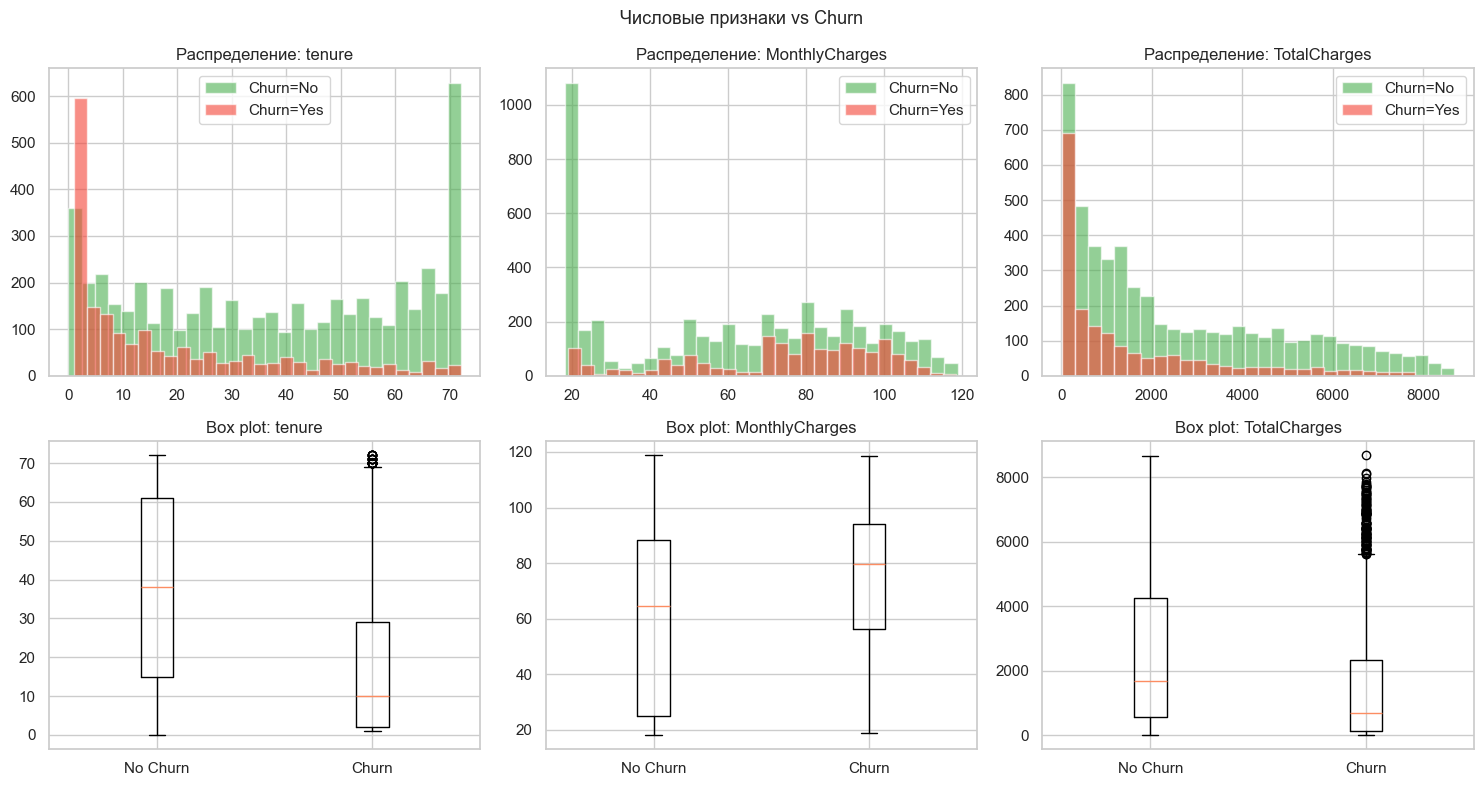

Наблюдения:
- tenure: клиенты с churn=1 имеют меньший стаж (уходят в начале)
- MonthlyCharges: у churned клиентов выше ежемесячная плата
- TotalCharges: коррелирует с tenure


In [8]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Конвертируем TotalCharges перед визуализацией
df_viz = df.copy()
df_viz['TotalCharges'] = pd.to_numeric(df_viz['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # Распределение
    for label, color in [('No', '#4CAF50'), ('Yes', '#F44336')]:
        subset = df_viz[df_viz['Churn'] == label][col].dropna()
        axes[0, i].hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}')
    axes[0, i].set_title(f'Распределение: {col}')
    axes[0, i].legend()

    # Box plot
    data_no = df_viz[df_viz['Churn'] == 'No'][col].dropna()
    data_yes = df_viz[df_viz['Churn'] == 'Yes'][col].dropna()
    axes[1, i].boxplot([data_no, data_yes], labels=['No Churn', 'Churn'])
    axes[1, i].set_title(f'Box plot: {col}')

plt.suptitle('Числовые признаки vs Churn', fontsize=13)
plt.tight_layout()
plt.show()

print('Наблюдения:')
print('- tenure: клиенты с churn=1 имеют меньший стаж (уходят в начале)')
print('- MonthlyCharges: у churned клиентов выше ежемесячная плата')
print('- TotalCharges: коррелирует с tenure')

## 5. Категориальные признаки

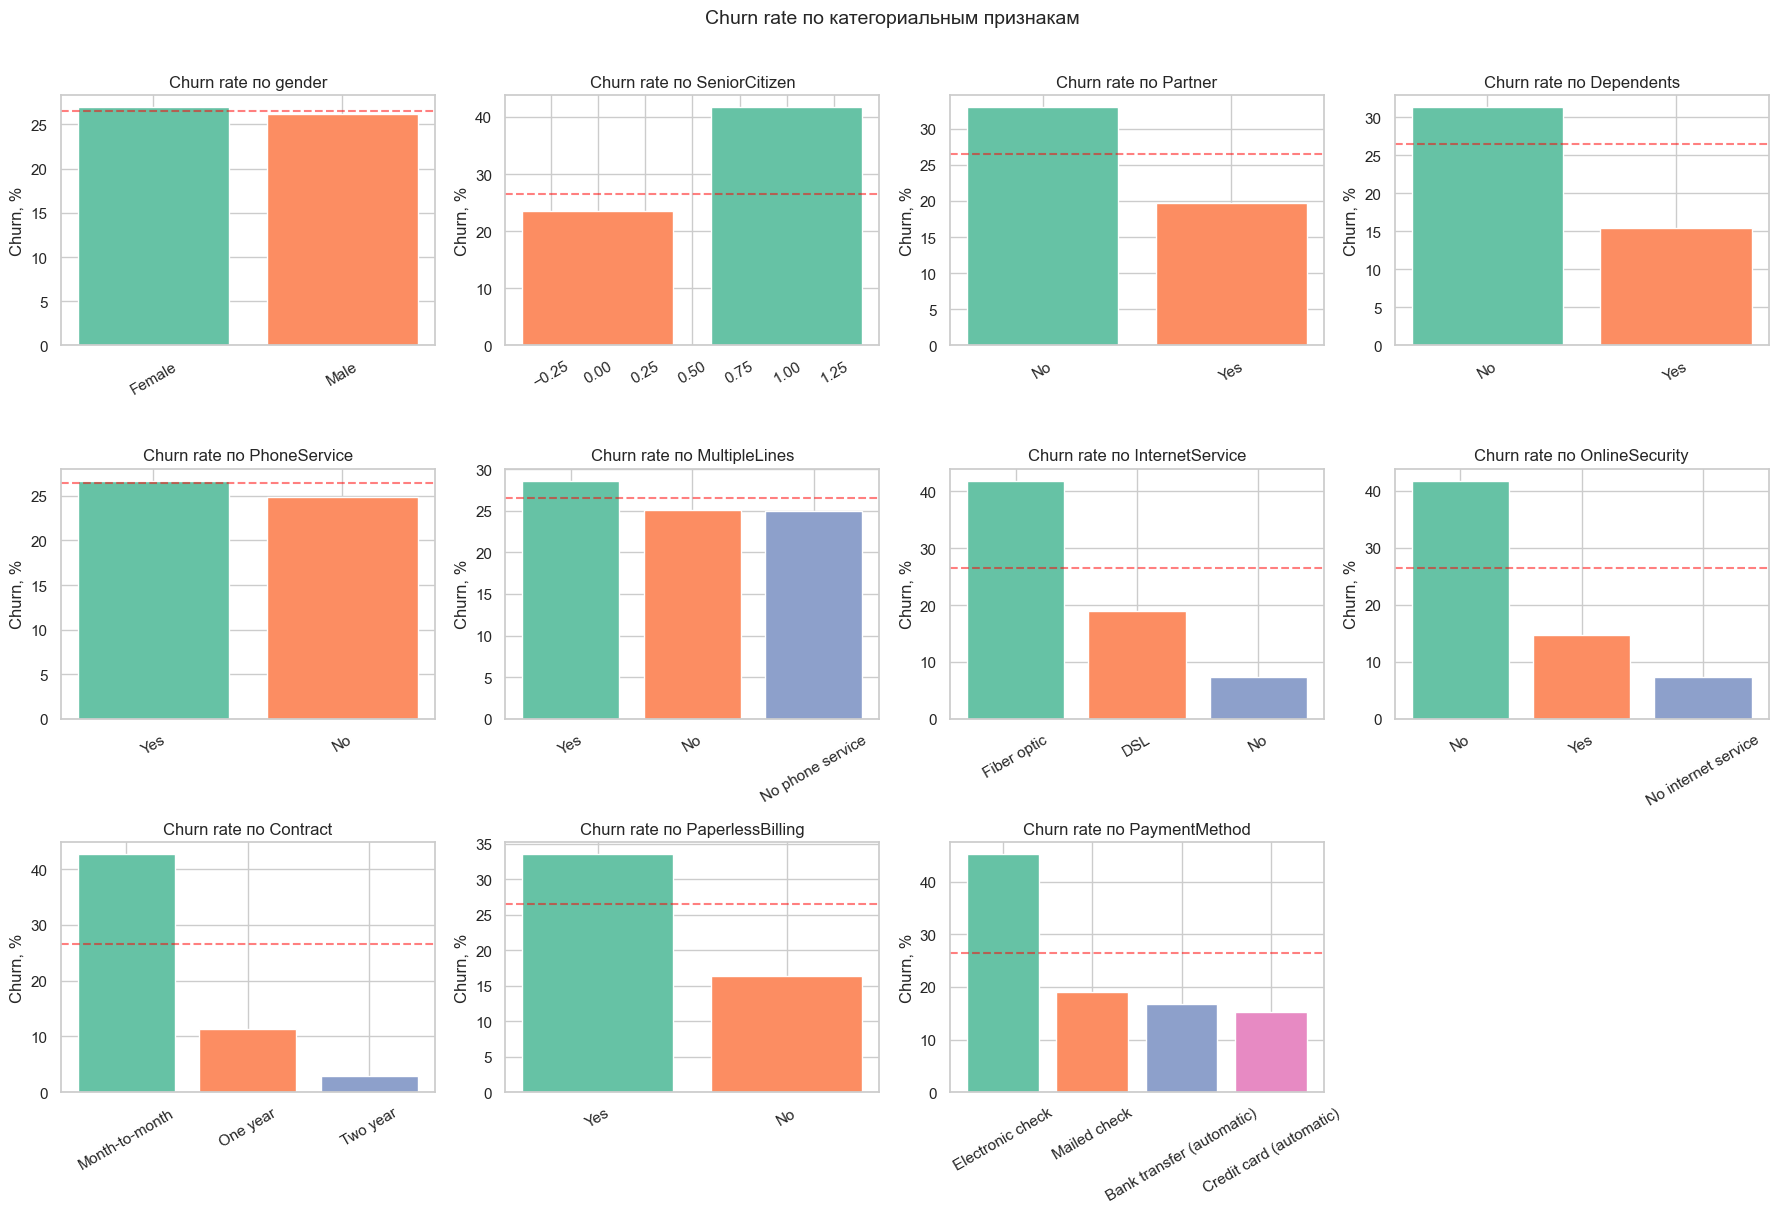

Ключевые наблюдения:
- Contract Month-to-month → churn ~43% (vs Two year ~3%)
- InternetService Fiber optic → churn ~42%
- OnlineSecurity No → churn ~42%
- PaperlessBilling Yes → churn ~34%


In [9]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
             'PhoneService', 'MultipleLines', 'InternetService',
             'OnlineSecurity', 'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)

    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=sns.color_palette('Set2', len(churn_rate)))
    axes[i].set_title(f'Churn rate по {col}')
    axes[i].set_ylabel('Churn, %')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=26.5, color='red', linestyle='--', alpha=0.5, label='среднее')

# Скрыть пустые подграфики
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn rate по категориальным признакам', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Ключевые наблюдения:')
print('- Contract Month-to-month → churn ~43% (vs Two year ~3%)')
print('- InternetService Fiber optic → churn ~42%')
print('- OnlineSecurity No → churn ~42%')
print('- PaperlessBilling Yes → churn ~34%')

## 6. Корреляционный анализ

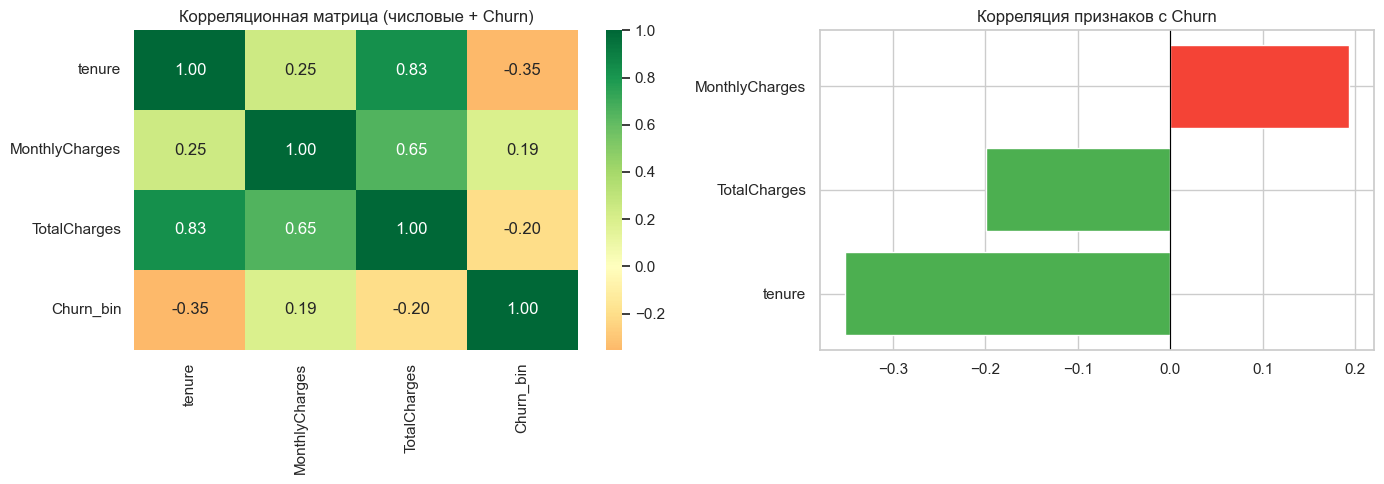

MonthlyCharges слабо положительно коррелирует с Churn
tenure отрицательно коррелирует с Churn (долгий стаж = ниже риск)


In [10]:
df_corr = df_viz.copy()
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)

# Числовые + бинарная цель
corr_data = df_corr[num_cols + ['Churn_bin']].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=axes[0])
axes[0].set_title('Корреляционная матрица (числовые + Churn)')

# Корреляция с Churn
churn_corr = corr_data.corr()['Churn_bin'].drop('Churn_bin').sort_values()
colors = ['#F44336' if v > 0 else '#4CAF50' for v in churn_corr.values]
axes[1].barh(churn_corr.index, churn_corr.values, color=colors)
axes[1].set_title('Корреляция признаков с Churn')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print('MonthlyCharges слабо положительно коррелирует с Churn')
print('tenure отрицательно коррелирует с Churn (долгий стаж = ниже риск)')

## 7. Предобработка (чеклист 3 + 5)

> Этот код **идентичен** `src/data/preprocessor.py` — принцип DRY.
> Сначала отрабатываем логику здесь, затем переносим в production-модуль.

In [11]:
def preprocess(df: pd.DataFrame, fit: bool = True,
                encoders: dict = None) -> tuple:
    """
    Полный пайплайн предобработки.

    Args:
        df:       исходный DataFrame
        fit:      True для train (обучает энкодеры), False для val/test
        encoders: словарь обученных LabelEncoder (для val/test)

    Returns:
        (X, y, encoders)
    """
    df = df.copy()

    # ── Шаг 1: Удалить customerID (не несёт смысла)
    df.drop(columns=['customerID'], inplace=True, errors='ignore')

    # ── Шаг 2: TotalCharges → float (пустые строки → NaN → median)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    if fit:
        tc_median = df['TotalCharges'].median()
        if encoders is None:
            encoders = {}
        encoders['TotalCharges_median'] = tc_median
    df['TotalCharges'].fillna(encoders['TotalCharges_median'], inplace=True)

    # ── Шаг 3: Целевая переменная
    y = None
    if 'Churn' in df.columns:
        y = (df['Churn'] == 'Yes').astype(int)
        df.drop(columns=['Churn'], inplace=True)

    # ── Шаг 4: Кодирование категориальных признаков (LabelEncoder)
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    if fit:
        for col in cat_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
    else:
        for col in cat_cols:
            le = encoders[col]
            # Обработка unseen labels
            known = set(le.classes_)
            df[col] = df[col].astype(str).apply(
                lambda x: x if x in known else le.classes_[0]
            )
            df[col] = le.transform(df[col])

    return df, y, encoders


print('Функция preprocess() определена')
print(f'Признаков до предобработки: {df.shape[1]}')

Функция preprocess() определена
Признаков до предобработки: 21


## 8. Разделение на train / val / test (stratified)

> Стратифицированное разбиение сохраняет соотношение классов в каждом сплите.
> Пропорция: 70% train / 15% val / 15% test.

In [12]:
# ── Разбиение 70 / 15 / 15 ──────────────────────────────────────────────────
train_df, temp_df = train_test_split(
    df, test_size=0.30,
    stratify=df['Churn'],
    random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['Churn'],
    random_state=RANDOM_STATE
)

print(f'Train: {len(train_df)} строк ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val:   {len(val_df)} строк ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test:  {len(test_df)} строк ({len(test_df)/len(df)*100:.1f}%)')

# Проверяем сохранение пропорций классов
print('\nChurn rate по сплитам:')
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    rate = (split['Churn'] == 'Yes').mean() * 100
    print(f'  {name}: {rate:.1f}%')

Train: 4930 строк (70.0%)
Val:   1056 строк (15.0%)
Test:  1057 строк (15.0%)

Churn rate по сплитам:
  train: 26.5%
  val: 26.5%
  test: 26.6%


In [13]:
# ── Применяем предобработку ────────────────────────────────────────────────
X_train, y_train, encoders = preprocess(train_df, fit=True)
X_val,   y_val,   _        = preprocess(val_df,   fit=False, encoders=encoders)
X_test,  y_test,  _        = preprocess(test_df,  fit=False, encoders=encoders)

print(f'X_train: {X_train.shape}, y_train: {y_train.value_counts().to_dict()}')
print(f'X_val:   {X_val.shape},   y_val:   {y_val.value_counts().to_dict()}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.value_counts().to_dict()}')
print(f'\nПризнаки: {X_train.columns.tolist()}')

X_train: (4930, 19), y_train: {0: 3622, 1: 1308}
X_val:   (1056, 19),   y_val:   {0: 776, 1: 280}
X_test:  (1057, 19),  y_test:  {0: 776, 1: 281}

Признаки: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## 9. Сохранение обработанных данных

In [14]:
import joblib

# Сохраняем сплиты
for name, X, y in [('train', X_train, y_train),
                    ('val',   X_val,   y_val),
                    ('test',  X_test,  y_test)]:
    df_out = X.copy()
    df_out['target'] = y
    out_path = DATA_PROCESSED / f'{name}.csv'
    df_out.to_csv(out_path, index=False)
    print(f'Сохранено: {out_path}')

# Сохраняем энкодеры (нужны при инференсе)
ARTIFACTS = Path('../artifacts')
ARTIFACTS.mkdir(parents=True, exist_ok=True)
encoders_path = ARTIFACTS / 'encoders.pkl'
joblib.dump(encoders, encoders_path)
print(f'Энкодеры сохранены: {encoders_path}')

Сохранено: ..\data\processed\train.csv
Сохранено: ..\data\processed\val.csv
Сохранено: ..\data\processed\test.csv
Энкодеры сохранены: ..\artifacts\encoders.pkl


## 10. Итоги EDA (чеклист 3)

| Наблюдение | Вывод |
|-----------|-------|
| Дисбаланс классов ~27%/73% | Используем ROC-AUC и F1 как основные метрики |
| `TotalCharges` — строковый тип | Исправлено: приведено к float, NaN → медиана |
| `Contract` сильно влияет на churn | Войдёт в топ важных признаков |
| `tenure` отрицательно коррелирует с churn | Долгий стаж снижает риск ухода |
| `InternetService: Fiber optic` → высокий churn | Возможно, проблема качества сервиса |

**Следующий шаг:** `notebooks/02_models.ipynb` — baseline и улучшенная модель (чеклист 4).